# 09 · Manuscript figures and conclusion summary

**Role in the story**: the wrap-up chapter. Aggregate the result tables from earlier notebooks into
one **manuscript-grade main result table**, and generate two composite main figures (OOD-gap
overview, per-drug OOD evidence table), all read from `results/notebooks/*` and `work/results/*`
without recomputation.

**Core claims (for the manuscript to cite)**

> On 18 Stanford HIVDB drugs, comparing three method families fairly and uniformly — binary
> encoding, ESM+linear, ESM+gradient-boosting: in-distribution they are close and binary encoding
> is already strong; explicit mutation fusion adds no gain (ESM has implicitly encoded the
> within-sequence information, which is highly consistent with clinical DRMs); yet under
> cross-subtype / cross-cluster out-of-distribution evaluation, **ESM+linear drops least, is most
> robust, and leads significantly on data-scarce hard drugs**. The value of the PLM is in OOD
> generalization, and evaluation protocols should move toward OOD.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "work" / "prepared").exists() else CWD.parent
RES = PROJECT_ROOT / "results" / "notebooks"
WR = PROJECT_ROOT / "work" / "results"
OUT_DIR = RES / "09_summary"
FIG_DIR = PROJECT_ROOT / "figures" / "mutation_aware" / "manuscript"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SURFACE, INK, INK2, INK3, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
CLASS_ORDER = ["PI", "NRTI", "NNRTI"]
CLASS_COLOR = {"PI": "#2a78d6", "NRTI": "#1baf7a", "NNRTI": "#eda100"}
METHOD_COLOR = {"binary": "#8a8984", "esm_lr": "#2a78d6", "esm_lgb": "#eb6834"}
GOOD, CRIT = "#0ca30c", "#d03b3b"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2, "axes.grid": False,
    "font.family": "DejaVu Sans",
})
print("project root:", PROJECT_ROOT)

project root: /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2


## 1 · Aggregate the main result table

Per drug: AUROC of the three methods under random CV / subtype OOD / cluster OOD, plus DRM
enrichment significance and whether fusion adds gain. All from existing result files.

In [2]:
ood = pd.read_csv(WR / "probe_ood.csv")
clu = pd.read_csv(WR / "probe_cluster_ood.csv")
enr = pd.read_csv(RES / "07_interpretability" / "enrichment_by_method.csv")
gain = pd.read_csv(RES / "05_models" / "fusion_gain_by_drug.csv")

enr_fd = enr[enr["method"] == "freq_delta"][["drug", "enrichment_ratio", "p_value"]].rename(
    columns={"enrichment_ratio": "drm_enrichment", "p_value": "drm_p"})
gain_small = gain[["drug", "gain_full_vs_esm"]]

main = clu[["class", "drug", "clu_binary", "clu_esm_lr", "clu_esm_lgb"]].merge(
    ood[["drug", "ood_binary", "ood_esm_lr", "ood_esm_lgb", "rg_esm_lr"]], on="drug", how="left"
).merge(enr_fd, on="drug", how="left").merge(gain_small, on="drug", how="left")

main["esm_lr_minus_binary_cluster"] = main["clu_esm_lr"] - main["clu_binary"]
main = main.rename(columns={"class": "drug_class", "rg_esm_lr": "random_esm_lr"})
main["drug_class"] = pd.Categorical(main["drug_class"], CLASS_ORDER, ordered=True)
main = main.sort_values(["drug_class", "clu_esm_lr"]).reset_index(drop=True)
main = main.round(4)
main.to_csv(OUT_DIR / "main_result_summary.csv", index=False)
print("wrote main_result_summary.csv  shape", main.shape)
main

wrote main_result_summary.csv  shape (18, 13)


,drug_class,drug,clu_binary,clu_esm_lr,clu_esm_lgb,ood_binary,ood_esm_lr,ood_esm_lgb,random_esm_lr,drm_enrichment,drm_p,gain_full_vs_esm,esm_lr_minus_binary_cluster
0,PI,TPV,0.8860,0.8884,0.8449,0.4721,0.6167,0.6000,0.9214,3.064,0.0,-0.0064,0.0024
1,PI,DRV,0.9588,0.9617,0.9509,0.8515,0.8195,0.8264,0.9728,3.300,0.0,-0.0027,0.0028
2,PI,FPV,0.9695,0.9665,0.9568,0.8693,0.8822,0.8238,0.9686,3.536,0.0,-0.0062,-0.0030
3,PI,NFV,0.9697,0.9689,0.9574,0.9478,0.9207,0.9580,0.9818,3.536,0.0,-0.0010,-0.0008
4,PI,ATV,0.9631,0.9767,0.9631,0.8409,0.8997,0.8290,0.9826,3.300,0.0,-0.0001,0.0136
5,PI,IDV,0.9725,0.9770,0.9600,0.9378,0.9402,0.9498,0.9835,3.536,0.0,-0.0030,0.0045
6,PI,LPV,0.9792,0.9795,0.9665,0.9329,0.9274,0.9307,0.9829,3.536,0.0,-0.0013,0.0003
7,PI,SQV,0.9796,0.9811,0.9707,0.9251,0.9273,0.9136,0.9863,3.536,0.0,-0.0005,0.0015
8,NRTI,DDI,0.6358,0.8060,0.7880,0.7000,0.6500,0.7357,0.8646,9.750,0.0,0.0049,0.1702
9,NRTI,TDF,0.7767,0.8595,0.8685,0.5874,0.6853,0.7797,0.9069,6.750,0.0,-0.0122,0.0827


In [3]:
claims = pd.DataFrame([
    {"claim": "In-distribution the three methods are close", "evidence": "esm_lr random-CV mean ~0.946, binary ~0.926, small gap", "notebook": "02/06"},
    {"claim": "Explicit mutation fusion adds no gain", "evidence": "full 0.9396 < esm_only 0.9462; 1/18 drugs positive", "notebook": "05"},
    {"claim": "ESM implicitly attends to clinical DRMs", "evidence": "all 3 sources 18/18 drugs significant, mean 4.8-5.6x", "notebook": "07"},
    {"claim": "esm_lr most robust OOD", "evidence": "cluster 0.923 > esm_lgb 0.902 > binary 0.892", "notebook": "06"},
    {"claim": "Value located on scarce hard drugs", "evidence": "esm_lr significantly beats binary on RPV/DDI/TDF/AZT", "notebook": "06"},
    {"claim": "Strong rep + simple model is best", "evidence": "esm+LR ceiling 0.9325 > binary+XGB 0.9211", "notebook": "08"},
    {"claim": "ESM implicitly encodes epistasis", "evidence": "explicit interaction OOD gain 17/18 negative; esm_lr>binary+int +0.036", "notebook": "08"},
])
claims.to_csv(OUT_DIR / "main_claims_table.csv", index=False)
claims

,claim,evidence,notebook
0,In-distribution the three methods are close,"esm_lr random-CV mean ~0.946, binary ~0.926, s...",02/06
1,Explicit mutation fusion adds no gain,full 0.9396 < esm_only 0.9462; 1/18 drugs posi...,05
2,ESM implicitly attends to clinical DRMs,"all 3 sources 18/18 drugs significant, mean 4....",07
3,esm_lr most robust OOD,cluster 0.923 > esm_lgb 0.902 > binary 0.892,06
4,Value located on scarce hard drugs,esm_lr significantly beats binary on RPV/DDI/T...,06
5,Strong rep + simple model is best,esm+LR ceiling 0.9325 > binary+XGB 0.9211,08
6,ESM implicitly encodes epistasis,explicit interaction OOD gain 17/18 negative; ...,08


## 2 · Main figure A: OOD-gap overview (three methods x three protocols)

A summary figure: random CV -> subtype OOD / cluster OOD, mean AUROC of the three methods. One
figure tells the core conclusion.

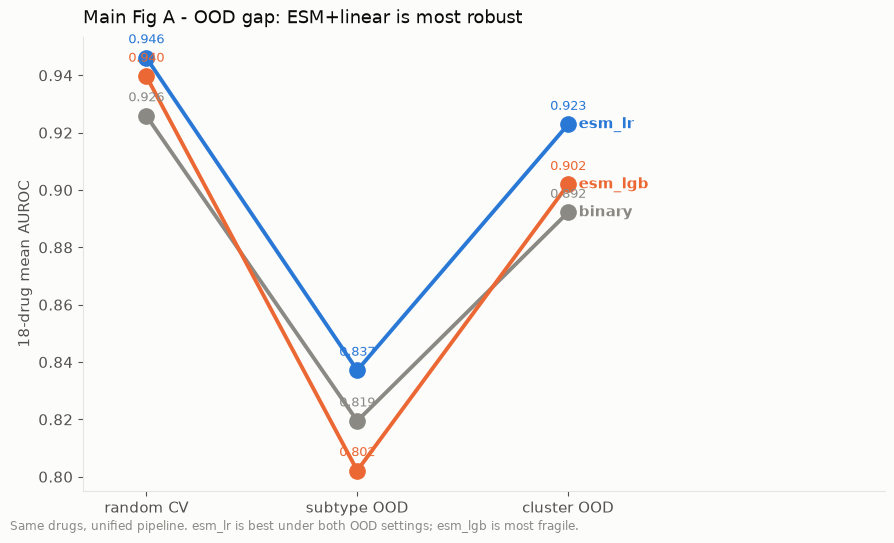

saved figA_ood_overview.png


In [4]:
rows = []
for m in ["binary", "esm_lr", "esm_lgb"]:
    rows.append({"method": m,
                 "random_cv": ood[f"rg_{m}"].mean(),
                 "subtype_ood": ood[f"ood_{m}"].mean(),
                 "cluster_ood": clu[f"clu_{m}"].mean()})
S = pd.DataFrame(rows).set_index("method")

fig, ax = plt.subplots(figsize=(9, 5.4))
stages = ["random_cv", "subtype_ood", "cluster_ood"]
labels = ["random CV", "subtype OOD", "cluster OOD"]
xs = np.arange(len(stages))
for m in ["binary", "esm_lr", "esm_lgb"]:
    ys = S.loc[m, stages].to_numpy(dtype=float)
    ax.plot(xs, ys, marker="o", markersize=11, lw=2.8, color=METHOD_COLOR[m], zorder=2)
    ax.text(xs[-1] + 0.05, ys[-1], m, ha="left", va="center", color=METHOD_COLOR[m],
            fontsize=11, fontweight="bold")
    for x, yv in zip(xs, ys):
        ax.text(x, yv + 0.004, f"{yv:.3f}", ha="center", va="bottom", color=METHOD_COLOR[m], fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_ylabel("18-drug mean AUROC")
ax.set_xlim(-0.3, len(stages) + 0.5)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.set_title("Main Fig A - OOD gap: ESM+linear is most robust", loc="left", color=INK, fontsize=13, pad=10)
fig.text(0.01, 0.005, "Same drugs, unified pipeline. esm_lr is best under both OOD settings; esm_lgb is most fragile.",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "figA_ood_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved figA_ood_overview.png")

## 3 · Main figure B: per-drug OOD evidence table (heat table)

A compact overview of drug x {cluster-OOD three methods + esm_lr-binary advantage + DRM enrichment
significance}, so one figure shows "which drugs ESM leads on, and whether the model signal lands on
clinical DRMs".

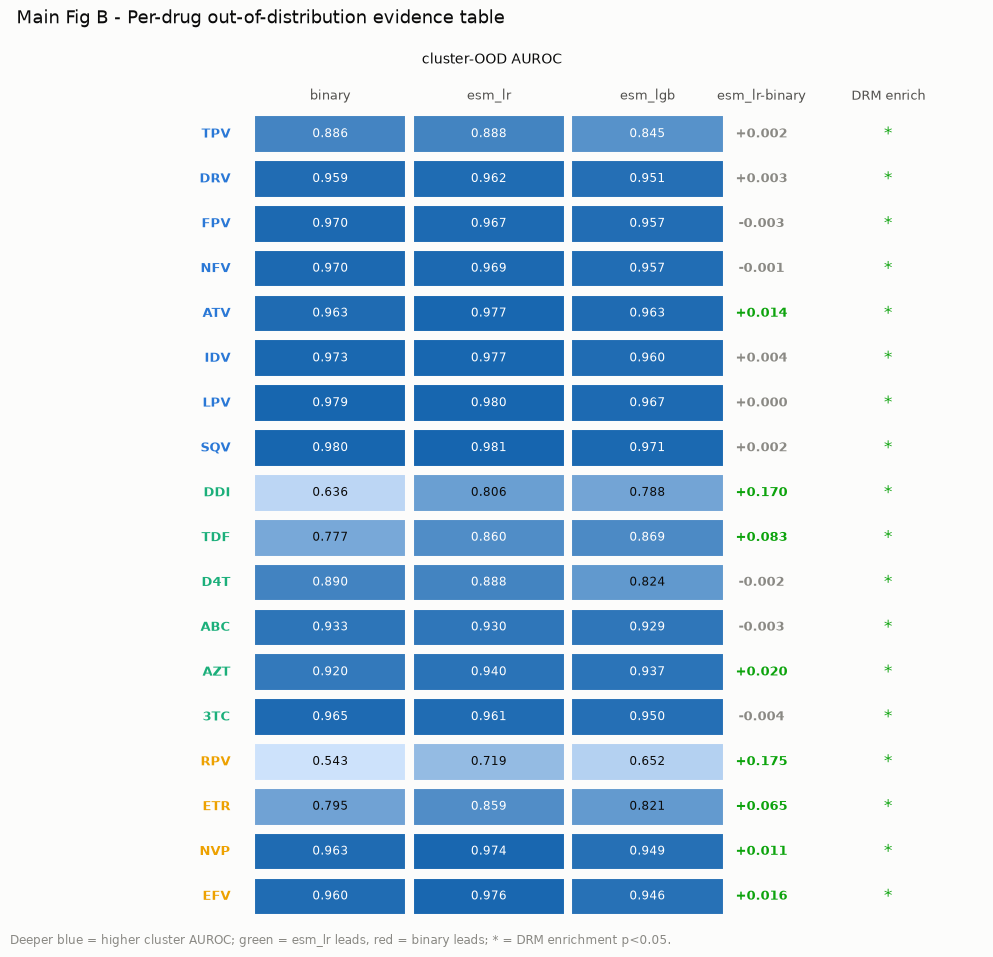

saved figB_perdrug_ood_evidence.png


In [5]:
M = main.copy()
drugs = M["drug"].tolist()
fig, ax = plt.subplots(figsize=(10, 0.42 * len(drugs) + 2.0))

def cell(x, y, val, vmin, vmax, fmt="{:.3f}"):
    frac = 0.0 if vmax <= vmin else (val - vmin) / (vmax - vmin)
    frac = min(1.0, max(0.0, frac))  # clamp so hex channels stay in 0-255
    r = int(round(205 + (13 - 205) * frac))
    g = int(round(226 + (95 - 226) * frac))
    b = int(round(251 + (171 - 251) * frac))
    clamp = lambda v: min(255, max(0, v))
    fill = f"#{clamp(r):02x}{clamp(g):02x}{clamp(b):02x}"
    ax.add_patch(plt.Rectangle((x, y - 0.42), 0.96, 0.84, facecolor=fill, edgecolor=SURFACE, lw=1.5))
    ax.text(x + 0.48, y, fmt.format(val), ha="center", va="center",
            color="#fff" if frac > 0.6 else INK, fontsize=8.5)

cols = ["clu_binary", "clu_esm_lr", "clu_esm_lgb"]
col_lab = ["binary", "esm_lr", "esm_lgb"]
vmin, vmax = 0.6, 1.0
for row, (_, r) in enumerate(M.iloc[::-1].reset_index(drop=True).iterrows()):
    y = row
    ax.text(-0.15, y, r["drug"], ha="right", va="center", color=CLASS_COLOR[r["drug_class"]],
            fontsize=9.5, fontweight="bold")
    for ci, c in enumerate(cols):
        cell(ci, y, r[c], vmin, vmax)
    adv = r["esm_lr_minus_binary_cluster"]
    ac = GOOD if adv > 0.01 else (INK3 if adv > -0.01 else CRIT)
    ax.text(3.2, y, f"{adv:+.3f}", ha="center", va="center", color=ac, fontsize=9, fontweight="bold")
    sig = "*" if (pd.notna(r["drm_p"]) and r["drm_p"] < 0.05) else "."
    ax.text(4.0, y, sig, ha="center", va="center", color=GOOD if sig == "*" else INK3, fontsize=12)

for ci, lab in enumerate(col_lab):
    ax.text(ci + 0.48, len(drugs) - 0.3, lab, ha="center", va="bottom", color=INK2, fontsize=9.5)
ax.text(3.2, len(drugs) - 0.3, "esm_lr-binary", ha="center", va="bottom", color=INK2, fontsize=9)
ax.text(4.0, len(drugs) - 0.3, "DRM enrich", ha="center", va="bottom", color=INK2, fontsize=9)
ax.text(1.5, len(drugs) + 0.5, "cluster-OOD AUROC", ha="center", va="bottom", color=INK, fontsize=10)

ax.set_xlim(-1.5, 4.6); ax.set_ylim(-0.8, len(drugs) + 1.1)
ax.axis("off")
ax.set_title("Main Fig B - Per-drug out-of-distribution evidence table", loc="left", color=INK, fontsize=13, pad=12)
fig.text(0.01, 0.005, "Deeper blue = higher cluster AUROC; green = esm_lr leads, red = binary leads; * = DRM enrichment p<0.05.",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "figB_perdrug_ood_evidence.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved figB_perdrug_ood_evidence.png")

## 4 · Main figure list and summary

**Generated manuscript main figures** (`figures/mutation_aware/manuscript/` and each chapter):

- Main Fig A: OOD-gap overview (this chapter, `figA_ood_overview.png`)
- Main Fig B: per-drug OOD evidence table (this chapter, `figB_perdrug_ood_evidence.png`)
- Reusable panel material: `02` headline reproducibility, `06` forest plot / slopegraph,
  `07` evidence funnel, `08` complexity matching / epistasis case.

**Conclusion tables**: `main_result_summary.csv` (per-drug OOD + enrichment + fusion gain),
`main_claims_table.csv` (7 core claims + evidence + source).

**One-sentence closure**: the right way to use a PLM for HIV drug-resistance prediction is to
"improve out-of-distribution robustness", and "strong representation + simple linear classifier"
delivers value on cross-subtype / cross-cluster generalization and on scarce hard drugs; explicit
mutation fusion adds no gain because that information is already implicitly encoded by the
representation and consistent with clinical DRMs.